# Notebook 09: Feature Importance and Error Analysis

What features drive the section classifier's predictions? Where does it fail and why?

In [7]:
import pandas as pd
import numpy as np
import joblib
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack
from sklearn.metrics import classification_report, confusion_matrix

#load saved section classifier
saved = joblib.load('../models/section_classifier.joblib')
model = saved['model']
tfidf = saved['tfidf']
scaler = saved['scaler']

feature_names = list(tfidf.get_feature_names_out()) + [
    'word_count', 'turn_count', 'doctor_words', 'patient_words', 'avg_turn_length'
]

print(f"Model: {type(model).__name__}")
print(f"Classes: {list(model.classes_)}")
print(f"Coefficients shape: {model.coef_.shape}")
print(f"Features: {len(feature_names)}")

Model: LogisticRegression
Classes: ['Assessment/Diagnosis', 'Chief Complaint', 'Exam/Review', 'History', 'Medications/Allergies', 'Plan/Disposition']
Coefficients shape: (6, 505)
Features: 505


/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1

## Top Features Per Class

Logistic Regression coefficients show which features matter most for each class. Positive coefficients raise the probability of the class, negative ones lower it.

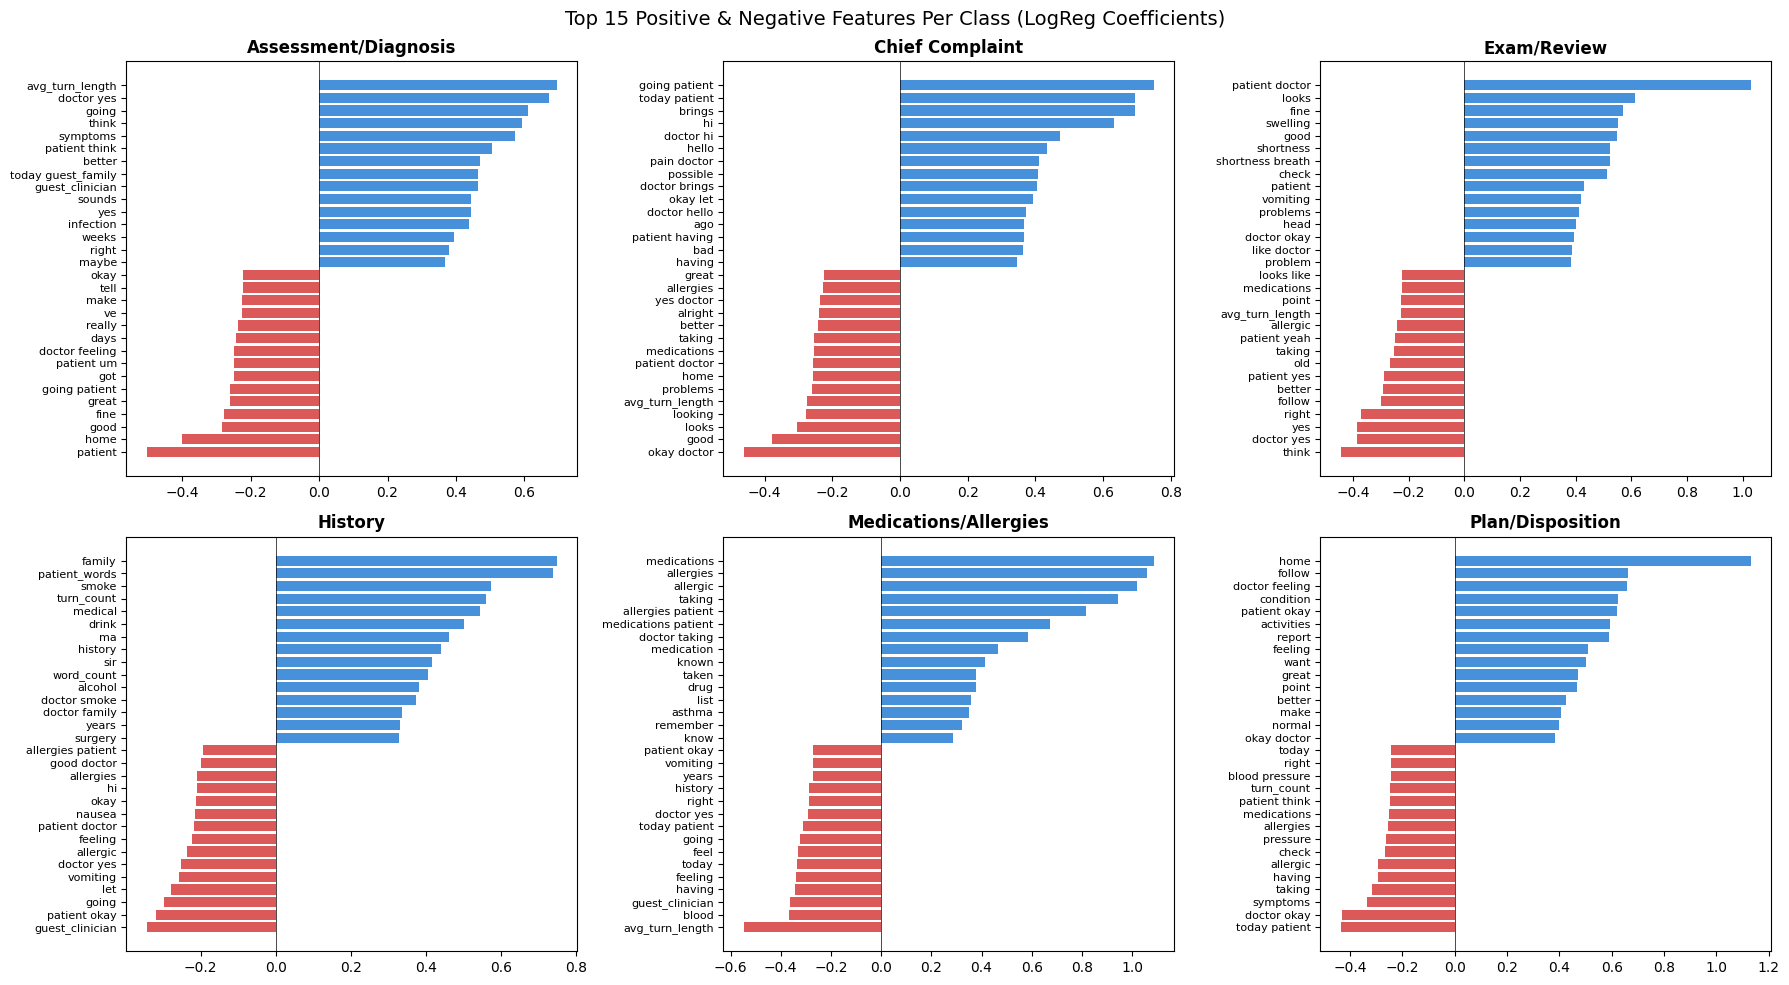

In [8]:
n_top = 15
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (cls, ax) in enumerate(zip(model.classes_, axes.flat)):
    coefs = model.coef_[idx]
    top_pos = np.argsort(coefs)[-n_top:]
    top_neg = np.argsort(coefs)[:n_top]
    top_idx = np.concatenate([top_neg, top_pos])

    colors = ['#d32f2f' if coefs[i] < 0 else '#1976d2' for i in top_idx]
    names = [feature_names[i] for i in top_idx]
    values = [coefs[i] for i in top_idx]

    ax.barh(range(len(top_idx)), values, color=colors, alpha=0.8)
    ax.set_yticks(range(len(top_idx)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(cls, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.5)

plt.suptitle('Top 15 Positive & Negative Features Per Class (LogReg Coefficients)', fontsize=14)
plt.tight_layout()
plt.show()

## Dialogue Feature Importance

How much do the 5 dialogue features actually contribute relative to TF-IDF?

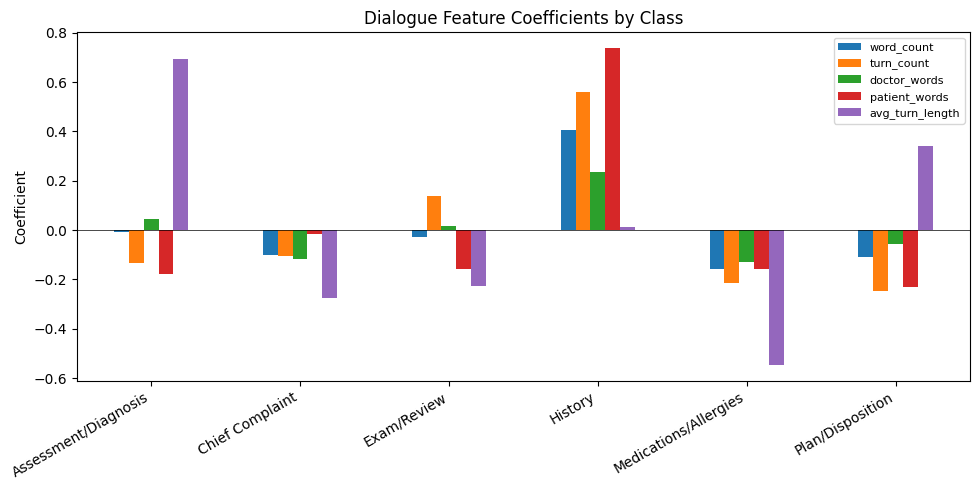

Dialogue feature coefficients:

                       word_count  turn_count  doctor_words  patient_words  avg_turn_length
Assessment/Diagnosis       -0.007      -0.132         0.047         -0.177            0.695
Chief Complaint            -0.103      -0.107        -0.116         -0.017           -0.273
Exam/Review                -0.028       0.140         0.017         -0.158           -0.228
History                     0.405       0.561         0.235          0.738            0.011
Medications/Allergies      -0.157      -0.214        -0.129         -0.156           -0.547
Plan/Disposition           -0.111      -0.248        -0.055         -0.230            0.342


In [9]:
#show dialogue feature coefficients across all classes
dialogue_features = ['word_count', 'turn_count', 'doctor_words', 'patient_words', 'avg_turn_length']
dialogue_idx = [feature_names.index(f) for f in dialogue_features]

dialogue_coefs = pd.DataFrame(
    model.coef_[:, dialogue_idx],
    index=model.classes_,
    columns=dialogue_features
)

fig, ax = plt.subplots(figsize=(10, 5))
dialogue_coefs.plot(kind='bar', ax=ax)
ax.set_title('Dialogue Feature Coefficients by Class')
ax.set_ylabel('Coefficient')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(loc='upper right', fontsize=8)
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Dialogue feature coefficients:\n")
print(dialogue_coefs.round(3).to_string())

## Error Analysis

Look at misclassified examples from the test sets and see if there's a pattern in the failures.

In [10]:
# Load test set and predict
section_mapping = {
    'GENHX': 'History', 'FAM/SOCHX': 'History', 'PASTMEDICALHX': 'History',
    'PASTSURGICAL': 'History', 'OTHER_HISTORY': 'History', 'GYNHX': 'History',
    'CC': 'Chief Complaint', 'ROS': 'Exam/Review', 'EXAM': 'Exam/Review',
    'ALLERGY': 'Medications/Allergies', 'MEDICATIONS': 'Medications/Allergies',
    'IMMUNIZATIONS': 'Medications/Allergies',
    'ASSESSMENT': 'Assessment/Diagnosis', 'DIAGNOSIS': 'Assessment/Diagnosis',
    'PLAN': 'Plan/Disposition', 'DISPOSITION': 'Plan/Disposition',
    'EDCOURSE': 'Plan/Disposition', 'PROCEDURES': 'Plan/Disposition',
    'IMAGING': 'Plan/Disposition', 'LABS': 'Plan/Disposition',
}

def extract_features(df):
    features = pd.DataFrame()
    features['word_count'] = df['dialogue'].str.split().str.len()
    features['turn_count'] = df['dialogue'].str.count(r'Doctor:|Patient:|\[doctor\]|\[patient\]')
    features['doctor_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Doctor|doctor).*?(?=Patient|patient|$)', x, re.DOTALL)).split()))
    features['patient_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Patient|patient).*?(?=Doctor|doctor|$)', x, re.DOTALL)).split()))
    features['avg_turn_length'] = features['word_count'] / features['turn_count'].clip(lower=1)
    return features

test_df = pd.read_csv('../data/raw/MTS-Dialog-TestSet-2-MEDIQA-Sum-2023.csv')
test_df['section_group'] = test_df['section_header'].map(section_mapping)

X_tfidf_test = tfidf.transform(test_df['dialogue'])
X_extra_test = extract_features(test_df)
X_test = hstack([X_tfidf_test, X_extra_test.values])
X_test_scaled = scaler.transform(X_test)

test_df['predicted'] = model.predict(X_test_scaled)
test_df['correct'] = test_df['section_group'] == test_df['predicted']

errors = test_df[~test_df['correct']].copy()
print(f"Total: {len(test_df)}, Correct: {test_df['correct'].sum()}, Errors: {len(errors)}")
print(f"\nMost common misclassification pairs:")
error_pairs = errors.groupby(['section_group', 'predicted']).size().sort_values(ascending=False)
print(error_pairs.head(10).to_string())

Total: 200, Correct: 150, Errors: 50

Most common misclassification pairs:
section_group         predicted            
History               Chief Complaint          8
                      Assessment/Diagnosis     4
Assessment/Diagnosis  Plan/Disposition         4
Plan/Disposition      Assessment/Diagnosis     4
History               Medications/Allergies    4
                      Exam/Review              3
Exam/Review           History                  3
                      Plan/Disposition         3
Plan/Disposition      History                  2
                      Exam/Review              2


In [11]:
#show example misclassified dialogues
print("=== Example Misclassifications ===\n")
for _, row in errors.head(5).iterrows():
    dialogue_preview = row['dialogue'][:200] + '...' if len(row['dialogue']) > 200 else row['dialogue']
    print(f"True: {row['section_group']}  |  Predicted: {row['predicted']}")
    print(f"Dialogue: {dialogue_preview}")
    print("-" * 80)

=== Example Misclassifications ===

True: Assessment/Diagnosis  |  Predicted: Medications/Allergies
Dialogue: Doctor: Are you taking Macrodantin?
Patient: Yes, I am.
Doctor: For your urine infection, right?
Patient: Yes.
Doctor: One hundred M G?
Patient: I think so.
Doctor: Okay so you had U T I because of th...
--------------------------------------------------------------------------------
True: Assessment/Diagnosis  |  Predicted: Plan/Disposition
Dialogue: Doctor: My diagnosis for you is aspiration pneumonia.
Patient: What kind of aspiration?
Doctor: Hydrocarbon.
Patient: Okay.
Doctor: And it is in both lungs that is causing infection. 
Patient: Also I ...
--------------------------------------------------------------------------------
True: Assessment/Diagnosis  |  Predicted: Chief Complaint
Dialogue: Doctor: Your lymph node is swollen. There are many reasons why a lymph node can become swollen. Since it has only been swollen for two days, I would like to monitor it.  
Patient: Oka

## Confidence on Correct vs Incorrect Predictions

Does the model know when it's wrong? If confidence on errors is lower than on correct predictions, that's a sign of well-calibrated probabilities.

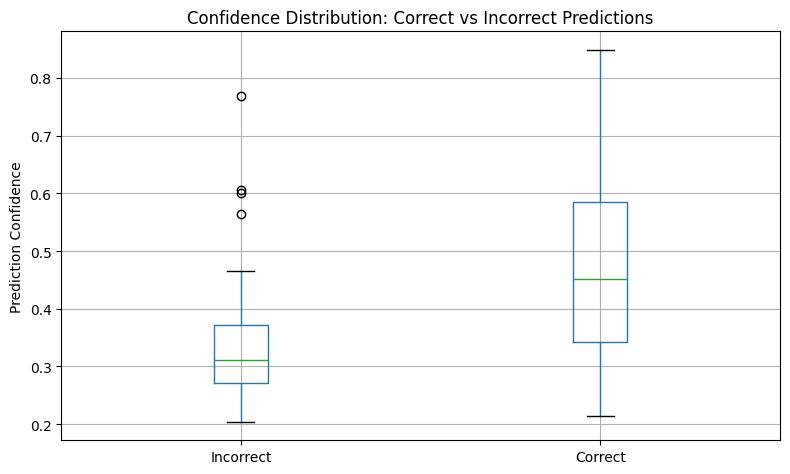

Mean confidence (correct):   0.472
Mean confidence (incorrect): 0.336


In [12]:
# predict_proba can fail on cross-version model loads, so use decision_function instead
decision = model.decision_function(X_test_scaled)

#convert decision function to pseudo-confidence (max across classes)
from scipy.special import softmax
probs = softmax(decision, axis=1)
test_df['confidence'] = probs.max(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
test_df.boxplot(column='confidence', by='correct', ax=ax)
ax.set_xticklabels(['Incorrect', 'Correct'])
ax.set_ylabel('Prediction Confidence')
ax.set_xlabel('')
ax.set_title('Confidence Distribution: Correct vs Incorrect Predictions')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(f"Mean confidence (correct):   {test_df[test_df['correct']]['confidence'].mean():.3f}")
print(f"Mean confidence (incorrect): {test_df[~test_df['correct']]['confidence'].mean():.3f}")